<a href="https://colab.research.google.com/github/Habila-Lima/engenharia-de-prompt-fundamentos/blob/main/Aula8_automacaoAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aula do dia 13/04, conteúdo automação com IA e exercícios práticos com o GeminiIA (Leitura de script, ghostwriter e tratamento de erros)

Nome: Hábila Moreira Lima


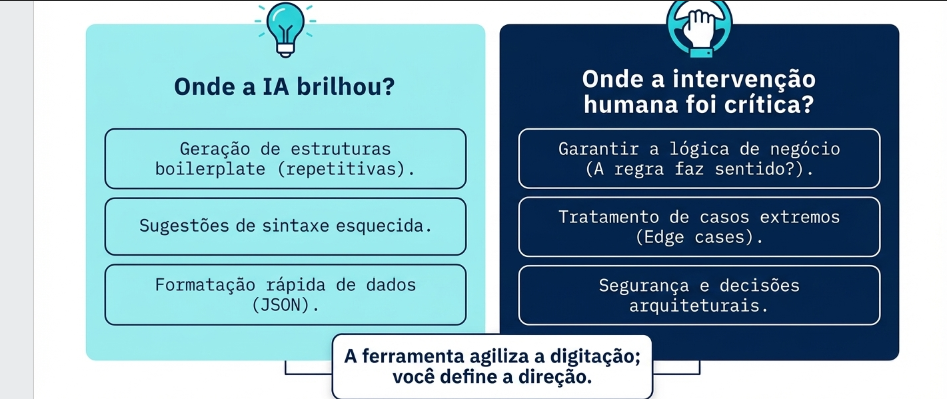


In [ ]:
# Dissecando um script
# crie um script simples para verificar a temperatura de um sistema:
# Se for maior que 30, exiba um alerta de superaquecimento.

temperature = 35  # Exemplo de temperatura

if temperature > 30:
    print("Alerta: Superaquecimento!")
else:
    print("Temperatura normal.")

Alerta: Superaquecimento!


In [ ]:
import os
import shutil

# Define o diretório de origem onde os arquivos estão localizados
# Por padrão, vamos usar o diretório atual do script
source_directory = '.'

# Define o diretório de destino onde as pastas organizadas serão criadas
destination_directory = 'Arquivos_Organizados'

# --- INÍCIO DA SIMULAÇÃO ---
print("Preparando para a simulação...")

# Limpa qualquer organização anterior para uma simulação limpa
if os.path.exists(destination_directory):
    print(f"Removendo diretório de destino anterior: {destination_directory}")
    shutil.rmtree(destination_directory)

# Cria o diretório de destino novamente, pois foi limpo
os.makedirs(destination_directory, exist_ok=True)

print("Criando arquivos de simulação...")
extensions_to_simulate = ['txt', 'pdf', 'docx', 'xlsx', 'jpg', 'mp3', 'png']

for ext in extensions_to_simulate:
    for i in range(1, 4): # Cria 3 arquivos para cada extensão
        filename = f'arquivo_simulacao_{i}.{ext}'
        filepath = os.path.join(source_directory, filename)
        with open(filepath, 'w') as f:
            f.write(f'Conteúdo do arquivo {filename}')
        print(f"Criado: {filename}")

# Cria 3 arquivos sem extensão
for i in range(1, 4):
    filename = f'arquivo_sem_extensao_{i}'
    filepath = os.path.join(source_directory, filename)
    with open(filepath, 'w') as f:
        f.write(f'Conteúdo do arquivo {filename}')
    print(f"Criado: {filename}")

print("Arquivos de simulação criados com sucesso!")
# --- FIM DA SIMULAÇÃO ---

print("Diretório de origem: " + os.path.abspath(source_directory))
print("Diretório de destino: " + os.path.abspath(destination_directory))
print("Iniciando a organização dos arquivos...")

# Itera sobre todos os itens no diretório de origem
for filename in os.listdir(source_directory):
    # Constrói o caminho completo para o arquivo ou diretório
    filepath = os.path.join(source_directory, filename)

    # Ignora diretórios e o próprio script de organização (removida a referência a __file__)
    # Também ignora o diretório de destino
    if os.path.isfile(filepath) and filename != destination_directory:
        # Obtém o nome do arquivo base e sua extensão
        name, extension = os.path.splitext(filename)

        # Remove o ponto da extensão e a converte para minúsculas para padronização
        # Se não houver extensão (ex: 'Makefile'), usa 'sem_extensao'
        if extension:
            folder_name = extension[1:].lower() # Remove o '.' inicial
        else:
            folder_name = 'sem_extensao'

        # Constrói o caminho completo para a nova pasta de tipo de documento
        type_folder_path = os.path.join(destination_directory, folder_name)

        # Cria a pasta para o tipo de documento se ela não existir
        os.makedirs(type_folder_path, exist_ok=True)

        # Constrói o caminho completo para onde o arquivo será movido
        destination_filepath = os.path.join(type_folder_path, filename)

        # Move o arquivo para a nova pasta
        # shutil.move lida com a movimentação e, se o arquivo já existir no destino,
        # ele o sobrescreverá por padrão. Tenha cuidado se isso não for o desejado.
        shutil.move(filepath, destination_filepath)
        print("Movido: '" + filename + "' para '" + type_folder_path + "'")

print("Organização concluída!")

Preparando para a simulação...
Removendo diretório de destino anterior: Arquivos_Organizados
Criando arquivos de simulação...
Criado: arquivo_simulacao_1.txt
Criado: arquivo_simulacao_2.txt
Criado: arquivo_simulacao_3.txt
Criado: arquivo_simulacao_1.pdf
Criado: arquivo_simulacao_2.pdf
Criado: arquivo_simulacao_3.pdf
Criado: arquivo_simulacao_1.docx
Criado: arquivo_simulacao_2.docx
Criado: arquivo_simulacao_3.docx
Criado: arquivo_simulacao_1.xlsx
Criado: arquivo_simulacao_2.xlsx
Criado: arquivo_simulacao_3.xlsx
Criado: arquivo_simulacao_1.jpg
Criado: arquivo_simulacao_2.jpg
Criado: arquivo_simulacao_3.jpg
Criado: arquivo_simulacao_1.mp3
Criado: arquivo_simulacao_2.mp3
Criado: arquivo_simulacao_3.mp3
Criado: arquivo_simulacao_1.png
Criado: arquivo_simulacao_2.png
Criado: arquivo_simulacao_3.png
Criado: arquivo_sem_extensao_1
Criado: arquivo_sem_extensao_2
Criado: arquivo_sem_extensao_3
Arquivos de simulação criados com sucesso!
Diretório de origem: /content
Diretório de destino: /content

### Consulta de CEP com ViaCEP

Este script permite consultar informações de endereço utilizando a API pública do ViaCEP. Ele inclui tratamento de erros para CEPs inválidos ou problemas de conexão e formata a saída para uma leitura mais fácil.

In [ ]:
import requests

def consultar_cep(cep):
    """
    Consulta a API do ViaCEP para obter informações de endereço.
    Trata erros de conexão e CEPs inválidos.
    Retorna um dicionário com os dados do endereço ou None em caso de erro.
    """
    # Remove caracteres não numéricos do CEP
    cep = ''.join(filter(str.isdigit, cep))

    # Valida o formato do CEP
    if len(cep) != 8:
        print(f"Erro: O CEP '{cep}' é inválido. Deve conter 8 dígitos numéricos.")
        return None

    url = f"https://viacep.com.br/ws/{cep}/json/"

    try:
        response = requests.get(url, timeout=5) # Adiciona um timeout para a requisição
        response.raise_for_status()  # Levanta um HTTPError para respostas de status de erro (4xx ou 5xx)
        data = response.json()

        # Verifica se a API do ViaCEP retornou erro (CEP não encontrado)
        if 'erro' in data and data['erro']:
            print(f"Erro: CEP '{cep}' não encontrado.")
            return None

        return data

    except requests.exceptions.HTTPError as http_err:
        print(f"Erro HTTP ao consultar o CEP '{cep}': {http_err}")
        return None
    except requests.exceptions.ConnectionError as conn_err:
        print(f"Erro de Conexão ao consultar o CEP '{cep}': {conn_err}\nVerifique sua conexão com a internet.")
        return None
    except requests.exceptions.Timeout as timeout_err:
        print(f"Timeout da Requisição ao consultar o CEP '{cep}': {timeout_err}\nO servidor do ViaCEP demorou muito para responder.")
        return None
    except requests.exceptions.RequestException as req_err:
        print(f"Ocorreu um erro inesperado ao consultar o CEP '{cep}': {req_err}")
        return None
    except Exception as e:
        print(f"Ocorreu um erro desconhecido ao processar o CEP '{cep}': {e}")
        return None

def formatar_endereco(endereco_data):
    """
    Formata os dados de endereço recebidos da API do ViaCEP para uma exibição legível.
    """
    if not endereco_data:
        return "Nenhuma informação de endereço disponível."

    formatado = []
    formatado.append(f"CEP: {endereco_data.get('cep', 'N/A')}")
    formatado.append(f"Logradouro: {endereco_data.get('logradouro', 'N/A')}")
    formatado.append(f"Complemento: {endereco_data.get('complemento', 'N/A')}")
    formatado.append(f"Bairro: {endereco_data.get('bairro', 'N/A')}")
    formatado.append(f"Localidade: {endereco_data.get('localidade', 'N/A')} - {endereco_data.get('uf', 'N/A')}")
    formatado.append(f"IBGE: {endereco_data.get('ibge', 'N/A')}")
    formatado.append(f"DDD: {endereco_data.get('ddd', 'N/A')}")

    return "\n".join(formatado)

# --- Exemplos de Uso ---
print("\n--- Exemplo 1: CEP Válido ---")
cep_valido = "01001-000" # Praça da Sé, São Paulo
dados_endereco = consultar_cep(cep_valido)
print(formatar_endereco(dados_endereco))

print("\n--- Exemplo 2: CEP Não Encontrado ---")
cep_nao_existente = "99999-999" # CEP fictício
dados_endereco_nao_encontrado = consultar_cep(cep_nao_existente)
print(formatar_endereco(dados_endereco_nao_encontrado))

print("\n--- Exemplo 3: CEP Inválido (formato) ---")
cep_formato_invalido = "12345"
dados_endereco_invalido = consultar_cep(cep_formato_invalido)
print(formatar_endereco(dados_endereco_invalido))

print("\n--- Exemplo 4: Outro CEP Válido ---")
cep_outro_valido = "20081-000" # Avenida Presidente Vargas, Rio de Janeiro
dados_endereco_outro = consultar_cep(cep_outro_valido)
print(formatar_endereco(dados_endereco_outro))


--- Exemplo 1: CEP Válido ---
CEP: 01001-000
Logradouro: Praça da Sé
Complemento: lado ímpar
Bairro: Sé
Localidade: São Paulo - SP
IBGE: 3550308
DDD: 11

--- Exemplo 2: CEP Não Encontrado ---
Erro: CEP '99999999' não encontrado.
Nenhuma informação de endereço disponível.

--- Exemplo 3: CEP Inválido (formato) ---
Erro: O CEP '12345' é inválido. Deve conter 8 dígitos numéricos.
Nenhuma informação de endereço disponível.

--- Exemplo 4: Outro CEP Válido ---
CEP: 20081-000
Logradouro: Rua Acre
Complemento: 
Bairro: Centro
Localidade: Rio de Janeiro - RJ
IBGE: 3304557
DDD: 21
